# (01) EyeMovies: explore

**Motivation**: <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_VIB'))
# from analysis.eval import sparse_score
from figures.fighelper import *
# from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

## Get dataloders

In [3]:
from base.dataset import make_dataloader

dl_trn, dl_vld = make_dataloader('EyeMovies64', device)
dl_trn_16, _ = make_dataloader('EyeMovies16', device)

<Axes: ylabel='Count'>

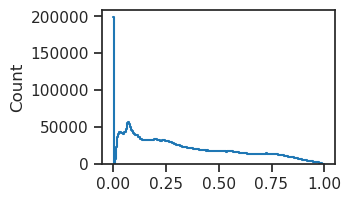

In [4]:
histplot(dl_trn.dataset.x[:1000].ravel())

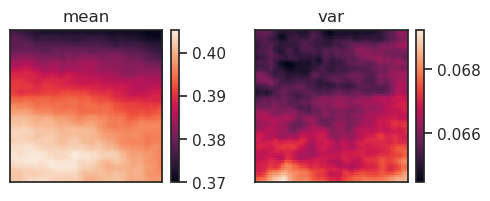

In [5]:
fig, axes = create_figure(1, 2, (5, 1.9), sharex='all', sharey='all')

im = axes[0].imshow(tonp(dl_trn.dataset.x.mean(0)))
plt.colorbar(im, ax=axes[0])

im = axes[1].imshow(tonp(dl_trn.dataset.x.var(0)))
plt.colorbar(im, ax=axes[1])

axes[0].set_title('mean')
axes[1].set_title('var')

remove_ticks(axes, False)
plt.show()

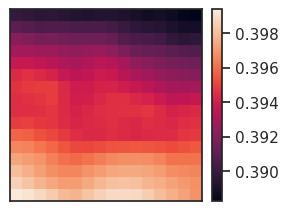

In [8]:
fig, ax = create_figure()
remove_ticks(ax, False)

plt.imshow(tonp(dl_trn_16.dataset.x.mean(0)))
plt.colorbar()

In [6]:
len(dl_trn.dataset)

136924

In [7]:
x, y = dl_trn.dataset[54]
x.shape, y.shape

(torch.Size([10, 64, 64]), torch.Size([1, 64, 64]))

In [8]:
from utils.animation import show_movie

In [9]:
show_movie(x)

In [10]:
delta = x[-1] - y[0]

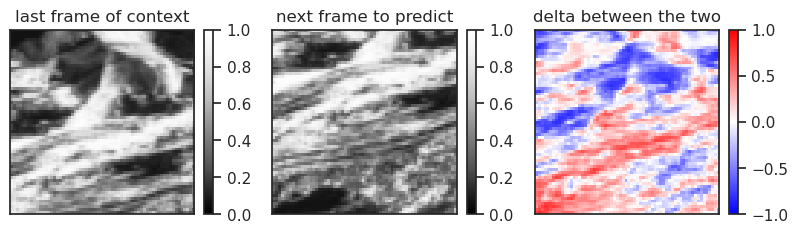

In [11]:
fig, axes = create_figure(1, 3, (8, 2.22), 'all', 'all')
remove_ticks(axes, False)

im = axes[0].imshow(tonp(x[-1]), cmap='Greys_r', vmin=0, vmax=1)
plt.colorbar(im, ax=axes[0])

im = axes[1].imshow(tonp(y[0]), cmap='Greys_r', vmin=0, vmax=1)
plt.colorbar(im, ax=axes[1])

im = axes[2].imshow(tonp(delta), cmap='bwr', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[2])

axes[0].set_title('last frame of context')
axes[1].set_title('next frame to predict')
axes[2].set_title('delta between the two')

plt.show()

In [12]:
torch.abs(delta).mean()

tensor(0.2822, device='cuda:0')

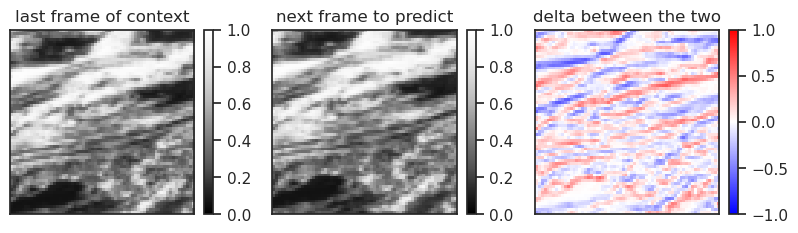

In [60]:
### Another example:

In [13]:
deltas = []

for x, y in iter(dl_trn):
    delta = x[:, -1] - y[:, 0]
    delta = torch.mean(torch.abs(
        delta), dim=(-2, -1))
    deltas.append(delta)

deltas = torch.cat(deltas)
deltas = tonp(deltas)
deltas.shape

(136924,)

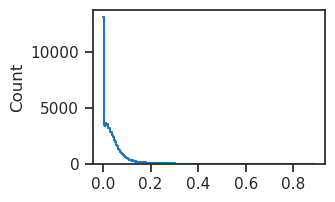

In [14]:
histplot(deltas);

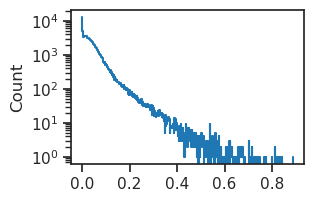

In [15]:
ax = histplot(deltas)
ax.set_yscale('log');